# 03. Bracken Community Structure

This notebook uses Bracken bacterial species counts for the main compositional analyses.


In [1]:
from pathlib import Path
import sys

import pandas as pd
from IPython.display import Markdown, SVG, display

ROOT = Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import workflow_core as wc

context, base_data, base, advanced = wc.bootstrap_notebook()

## Build Pairwise Community Distances


In [2]:
analysis_context = wc.base_analysis_context(context)
metadata = base_data["metadata"]
qc = base_data["qc"]
species_bac = base_data["species_bac"]

community_samples = qc.index[qc["community_qc_pass"]].tolist()
rel_abundance = base.community_relative_abundance(species_bac, community_samples)
pairwise = base.summarize_pairwise_distances(rel_abundance, metadata)

from scipy.stats import mannwhitneyu
import matplotlib.pyplot as plt
import seaborn as sns

site_map = metadata["body_region"].to_dict()
pairwise["same_body_site"] = pairwise["sample_i"].map(site_map).eq(
    pairwise["sample_j"].map(site_map)
)

order = [
    "Same patient, same batch date",
    "Same patient, same body site",
    "Same patient, different date/site",
    "Different patient",
]
new_tick_labels = [
    "Same patient,\nsame date",
    "Same patient,\nsame site",
    "Same patient,\ndiff date/site",
    "Diff patient",
]

same_date_mask = pairwise["same_patient"] & pairwise["same_batch"]
same_site_mask = (
    pairwise["same_patient"] & pairwise["same_body_site"] & ~same_date_mask
)
diff_date_site_mask = pairwise["same_patient"] & ~(same_date_mask | same_site_mask)

plot_pairwise = pd.concat(
    [
        pairwise.loc[
            same_date_mask,
            ["distance"],
        ].assign(comparison_group=order[0]),
        pairwise.loc[
            same_site_mask,
            ["distance"],
        ].assign(comparison_group=order[1]),
        pairwise.loc[
            diff_date_site_mask,
            ["distance"],
        ].assign(comparison_group=order[2]),
        pairwise.loc[~pairwise["same_patient"], ["distance"]].assign(
            comparison_group=order[3]
        ),
    ],
    ignore_index=True,
)

summary = (
    plot_pairwise.groupby("comparison_group")["distance"]
    .agg(["count", "median", "mean"])
    .reindex(order)
    .reset_index()
)

pvalue_rows = []
reference = plot_pairwise.loc[
    plot_pairwise["comparison_group"] == "Different patient", "distance"
]
for group in order[:-1]:
    test = plot_pairwise.loc[plot_pairwise["comparison_group"] == group, "distance"]
    statistic = mannwhitneyu(test, reference, alternative="less")
    pvalue_rows.append(
        {
            "comparison_group": group,
            "reference_group": "Different patient",
            "pvalue": statistic.pvalue,
            "median_difference": test.median() - reference.median(),
        }
    )
pvalues = base.bh_adjust(pd.DataFrame(pvalue_rows), "pvalue")


fig, ax = plt.subplots(figsize=(4.5, 5))

sns.boxplot(
    data=plot_pairwise,
    x="comparison_group",
    y="distance",
    order=order,
    color="#dfe7d6",
    fliersize=0,
    width=0.6,
    ax=ax,
)
sns.stripplot(
    data=plot_pairwise.sample(min(plot_pairwise.shape[0], 4000), random_state=7),
    x="comparison_group",
    y="distance",
    order=order,
    color="#3f4d3c",
    alpha=0.25,
    size=3,
    ax=ax,
)

ax.set_xlabel("")
ax.set_ylabel("Bray-Curtis distance")
# ax.set_title("Descriptive Bray-Curtis similarity by patient and batch-date grouping")
ax.set_xticklabels(new_tick_labels, rotation=30, ha="right")


def add_pvalue_bracket(
    ax: plt.Axes,
    x1: int,
    x2: int,
    y: float,
    h: float,
    text: str,
    fontsize: int = 9,
) -> None:
    """Draw a bracket with annotation between two x positions.

    Args:
        ax: Matplotlib axes to draw on.
        x1: Left x position.
        x2: Right x position.
        y: Baseline y position for the bracket.
        h: Height of the bracket.
        text: Annotation text to place above the bracket.
        fontsize: Font size for the annotation.
    """
    ax.plot(
        [x1, x1, x2, x2],
        [y, y + h, y + h, y],
        lw=1.2,
        c="black",
        clip_on=False,
    )
    ax.text(
        (x1 + x2) / 2,
        y + h,
        text,
        ha="center",
        va="bottom",
        fontsize=fontsize,
    )


group_to_x = {group_name: idx for idx, group_name in enumerate(order)}

y_start = 1.02
y_step = 0.1
bracket_height = 0.02

for idx, row in pvalues.reset_index(drop=True).iterrows():
    x1 = group_to_x[row["comparison_group"]]
    x2 = group_to_x[row["reference_group"]]
    y = y_start + idx * y_step

    add_pvalue_bracket(
        ax=ax,
        x1=min(x1, x2),
        x2=max(x1, x2),
        y=y,
        h=bracket_height,
        text=f"q={row['qvalue']:.3g}",
        fontsize=12,
    )

ax.set_ylim(0, y_start + len(pvalues) * y_step)
# Remove y ticks beyond 1
ax.set_yticks([tick for tick in ax.get_yticks() if tick <= 1])


fig.tight_layout()
fig_path = wc.figure_path(context, 2, "pairwise_distance")
fig.show()
fig.savefig(fig_path, bbox_inches="tight")
fig.savefig(fig_path.with_suffix(".jpg"), bbox_inches="tight", dpi=300)
plt.close(fig)

summary = summary.merge(pvalues, on="comparison_group", how="left")

wc.save_table(pairwise, wc.table_path(context, 4, "pairwise_distances"))
wc.save_table(summary, wc.table_path(context, 5, "pairwise_distance_summary"))

/tmp/ipykernel_3387708/2120294891.py:110: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_tick_labels, rotation=30, ha="right")


PosixPath('/home/ubuntu/dev/20250320_eb_summary/metagenomics_20260206/analysis_update/tables/table_03_02_pairwise_distance_summary.tsv')


## Review Numbered Outputs


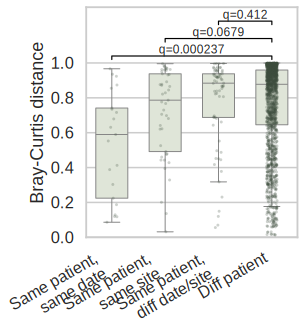

,comparison_group,count,median,mean,reference_group,pvalue,median_difference,qvalue
0,"Same patient, same batch date",21,0.589725,0.531767,Different patient,0.000079,-0.288016,0.000237
1,"Same patient, same body site",45,0.786647,0.715692,Different patient,0.045283,-0.091094,0.067924
2,"Same patient, different date/site",69,0.884231,0.773864,Different patient,0.411852,0.006490,0.411852
3,Different patient,1695,0.877741,0.764694,NaN,NaN,NaN,NaN


## Working Interpretation
- Positive result: same-patient same-batch-date swabs were much closer than unrelated swabs (median Bray-Curtis 0.590 vs 0.878).
- Positive result: same-patient same-site pairs also showed lower dissimilarity than unrelated pairs (median 0.787 vs 0.878).
- Negative result: same-patient different date/site pairs were closer to unrelated pairs (median 0.884).
- Interpretation: descriptive patient-date grouping is informative, but later models treat absolute date as technical batch rather than biology.

In [3]:
pairwise = pd.read_csv(wc.table_path(context, 4, "pairwise_distances"), sep="\t")
summary = pd.read_csv(wc.table_path(context, 5, "pairwise_distance_summary"), sep="\t")

display(SVG(filename=str(wc.figure_path(context, 2, "pairwise_distance"))))
display(summary)

same_visit = summary.loc[
    summary["comparison_group"] == "Same patient, same batch date"
].iloc[0]
same_site = summary.loc[
    summary["comparison_group"] == "Same patient, same body site"
].iloc[0]
diff_date_site = summary.loc[
    summary["comparison_group"] == "Same patient, different date/site"
].iloc[0]
different = summary.loc[summary["comparison_group"] == "Different patient"].iloc[0]
summary_lines = [
    f"- Positive result: same-patient same-batch-date swabs were much closer than unrelated swabs (median Bray-Curtis {same_visit['median']:.3f} vs {different['median']:.3f}).",
    f"- Positive result: same-patient same-site pairs also showed lower dissimilarity than unrelated pairs (median {same_site['median']:.3f} vs {different['median']:.3f}).",
    f"- Negative result: same-patient different date/site pairs were closer to unrelated pairs (median {diff_date_site['median']:.3f}).",
    "- Interpretation: descriptive patient-date grouping is informative, but later models treat absolute date as technical batch rather than biology.",
]
display(Markdown("## Working Interpretation\n" + "\n".join(summary_lines)))